### Imports

In [58]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

### Global variables

In [59]:
model_list = ["logreg", "mlp", "svm"]  # add other models if needed
aggregation_method = "fedavg"   # "fedavg" or "fedprox" or "scaffold"
distribution = "iid"    # "iid" or "non-iid"

### Paths

In [60]:
cwd = Path.cwd()
if (cwd / 'runs').exists():
    base = cwd / 'runs'
elif cwd.name == 'runs':
    base = cwd
else:
    base = cwd / 'runs'


paths = {}

for model in model_list:
    paths[f"{aggregation_method}-{model}-{distribution}"] = base / f"{aggregation_method}-{model}-{distribution}"

### Utils

In [61]:
def load_global_metrics(run_path: Path) -> pd.DataFrame:
    global_csv = run_path / 'global_metrics.csv'
    metrics_csv = run_path / 'metrics.csv'
    if global_csv.exists():
        return pd.read_csv(global_csv)
    if metrics_csv.exists():
        return pd.read_csv(metrics_csv)
    raise FileNotFoundError(f'No global metrics CSV in {run_path}')


def load_comm_costs(run_path: Path):
    path = run_path / 'comm_costs.csv'
    return pd.read_csv(path) if path.exists() else None


def load_run_time(run_path: Path):
    path = run_path / 'run_metrics.csv'
    if not path.exists():
        return None
    df = pd.read_csv(path)
    row = df[df['metric'] == 'run_time_seconds']
    if row.empty:
        return None
    return float(row['value'].iloc[0])

### Graphs

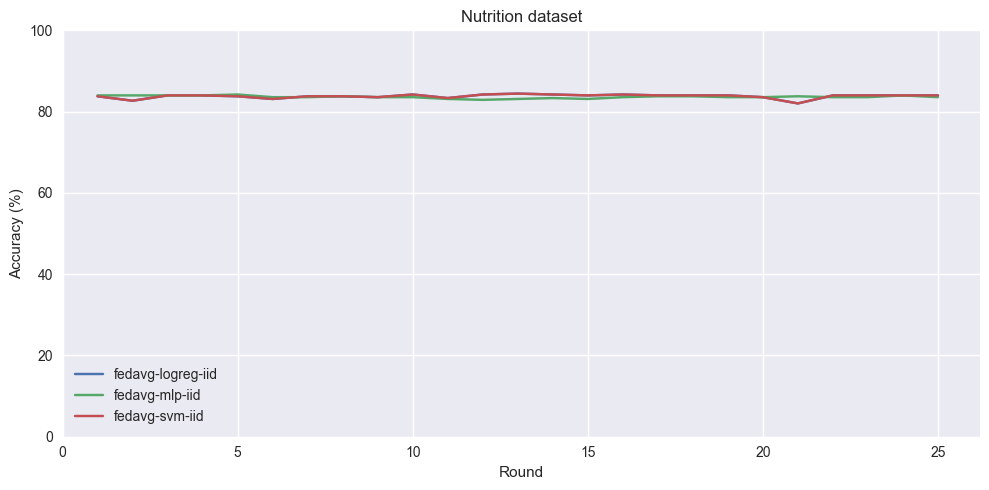

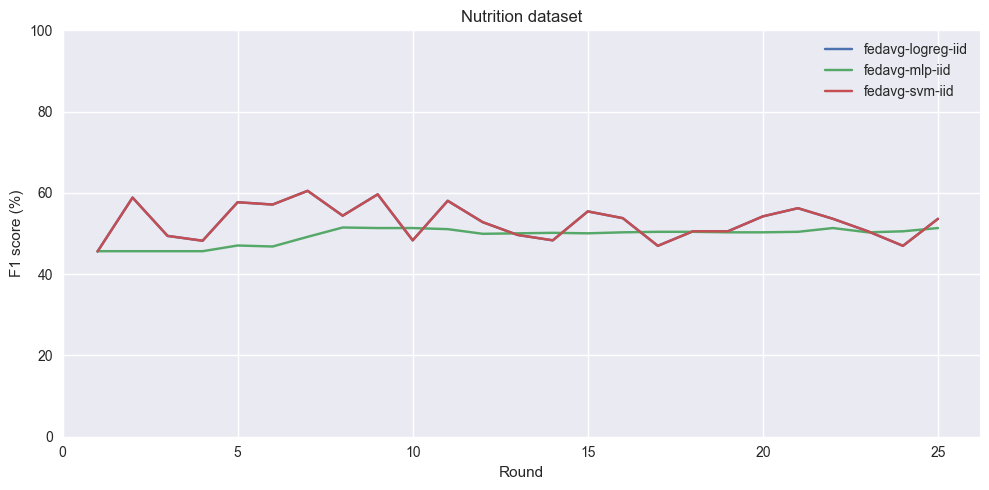

In [62]:
metrics = {name: load_global_metrics(path) for name, path in paths.items()}
legend_map = {}
color_map = {}

plt.figure(figsize=(10, 5))
for name, df in metrics.items():
    plt.plot(
        df['round'],
        df['accuracy'] * 100,
        label=legend_map.get(name, name),
        color=color_map.get(name),
    )
plt.title('Nutrition dataset')
plt.xlabel('Round')
plt.ylabel('Accuracy (%)')
plt.xlim(left=0)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
for name, df in metrics.items():
    if 'macro_f1' in df.columns:
        plt.plot(
            df['round'],
            df['macro_f1'] * 100,
            label=legend_map.get(name, name),
            color=color_map.get(name),
        )
plt.title('Nutrition dataset')
plt.xlabel('Round')
plt.ylabel('F1 score (%)')
plt.xlim(left=0)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

The logistic regression and svm models have the same graphs. The mlp is more interresting in our case because the stability of the f1. Note that using MLP can become costly in case of decentralized learning, but this it not our purpose.


fedavg-logreg-iid: 4080 bytes
fedavg-mlp-iid: 677790 bytes
fedavg-svm-iid: 4080 bytes
{'fedavg-logreg-iid': np.float64(0.01556396484375), 'fedavg-mlp-iid': np.float64(2.5855636596679688), 'fedavg-svm-iid': np.float64(0.01556396484375)}
[np.float64(0.01556396484375), np.float64(2.5855636596679688), np.float64(0.01556396484375)]


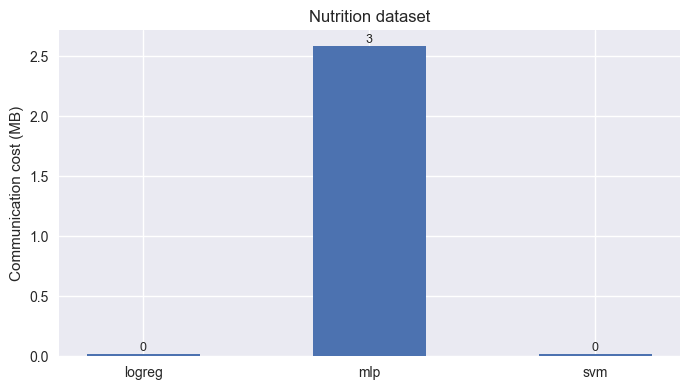

In [63]:
comm_totals = {}
for name, path in paths.items():
    df = load_comm_costs(path)
    comm_totals[name] = df['comm_costs'].sum() if df is not None else 0

print()

for k, v in comm_totals.items():
    print(f"{k}: {v} bytes")

bytes_per_param = 4
comm_totals_mb = {k: (v * bytes_per_param) / (1024**2) for k, v in comm_totals.items()}


print(comm_totals_mb)

order = paths.keys()
labels = model_list
#colors = ['#264653', '#2A9D8F', '#E76F51']  #['#264653', '#2A9D8F', '#E76F51']
values = [comm_totals_mb.get(k, 0) for k in order]
print(values)

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, values, width=0.5)
plt.title('Nutrition dataset')
plt.ylabel('Communication cost (MB)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0f}',
             ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

{'fedavg-logreg-iid': 2.204954499960877, 'fedavg-mlp-iid': 3.053752300038468, 'fedavg-svm-iid': 2.256547899974976}
[2.204954499960877, 3.053752300038468, 2.256547899974976]


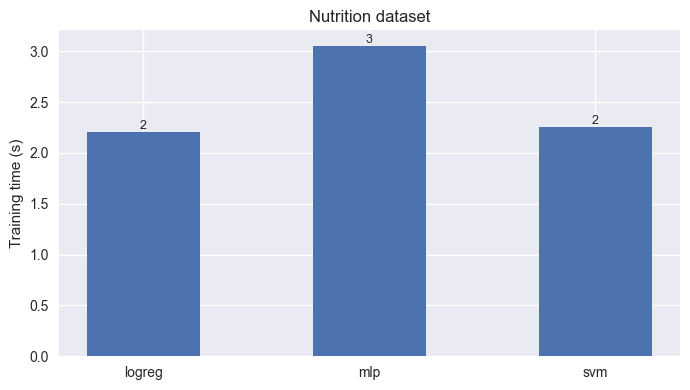

In [64]:
run_times = {name: load_run_time(path) for name, path in paths.items()}

print(run_times)

order = paths.keys()
labels = model_list
#colors = ['#264653', '#2A9D8F', '#E76F51']
values = [run_times.get(k, 0) if run_times.get(k) is not None else 0 for k in order]

print(values)

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, values,  width=0.5)
plt.title('Nutrition dataset')
plt.ylabel('Training time (s)')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.0f}',
             ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## Non-iid

In [65]:
name = f"{aggregation_method}-mlp-non_iid"
path = base / name
print(path)



d:\INSA_Lyon\2nd_semester\Federated_learning\M1_Federated_learning\project_medical_fl_implementation\runs\fedavg-mlp-non_iid


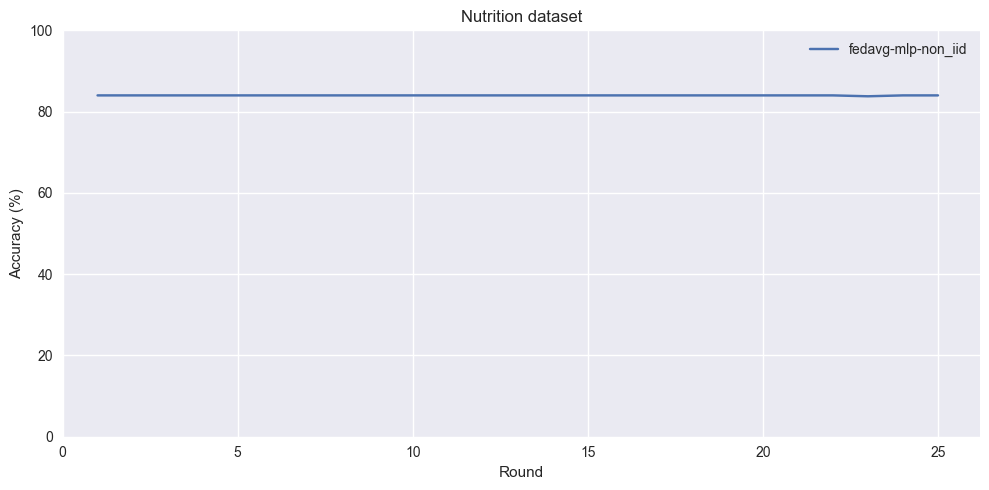

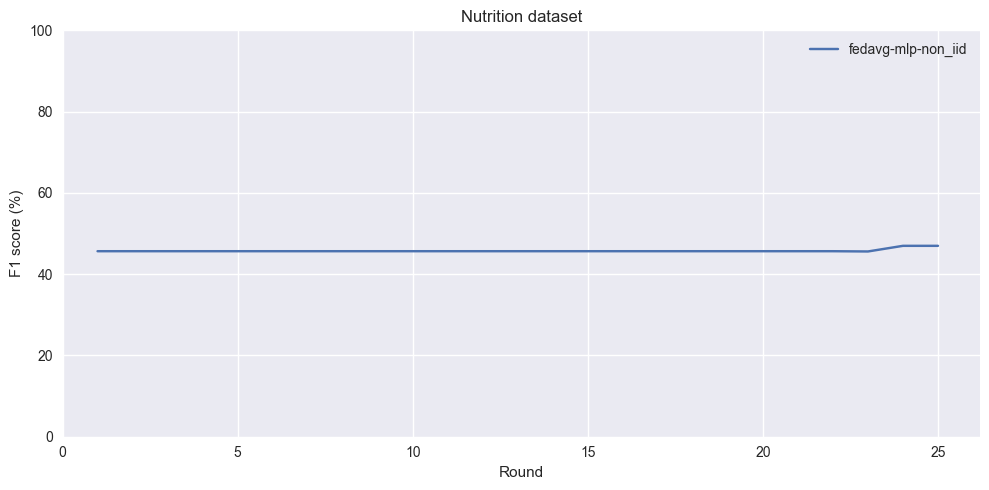

In [66]:
metric = {name: load_global_metrics(path)}
legend_map = {}
color_map = {}

plt.figure(figsize=(10, 5))
for name, df in metric.items():
    plt.plot(
        df['round'],
        df['accuracy'] * 100,
        label=legend_map.get(name, name),
        color=color_map.get(name),
    )
plt.title('Nutrition dataset')
plt.xlabel('Round')
plt.ylabel('Accuracy (%)')
plt.xlim(left=0)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
for name, df in metric.items():
    if 'macro_f1' in df.columns:
        plt.plot(
            df['round'],
            df['macro_f1'] * 100,
            label=legend_map.get(name, name),
            color=color_map.get(name),
        )
plt.title('Nutrition dataset')
plt.xlabel('Round')
plt.ylabel('F1 score (%)')
plt.xlim(left=0)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

### Non-iid + DCP

In [67]:
name = f"{aggregation_method}-mlp-non_iid-dcp"
path = base / name
print(path)



d:\INSA_Lyon\2nd_semester\Federated_learning\M1_Federated_learning\project_medical_fl_implementation\runs\fedavg-mlp-non_iid-dcp


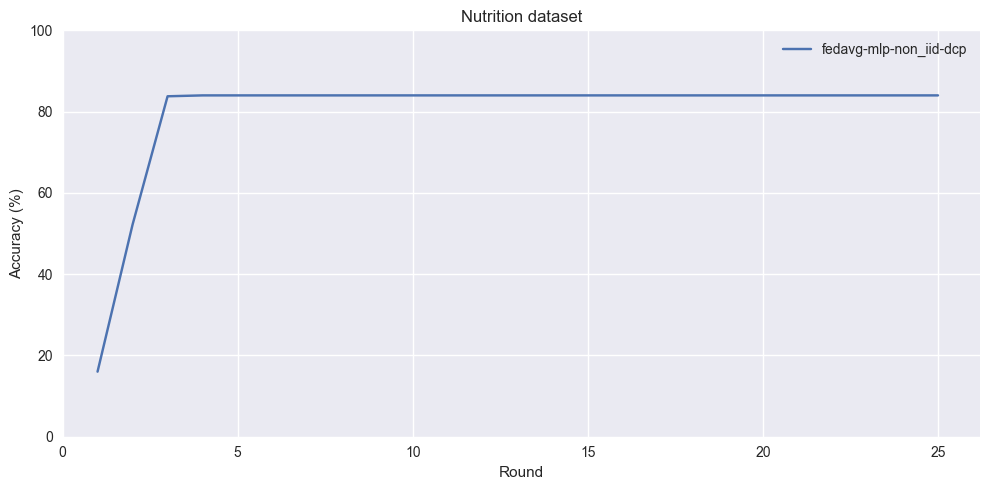

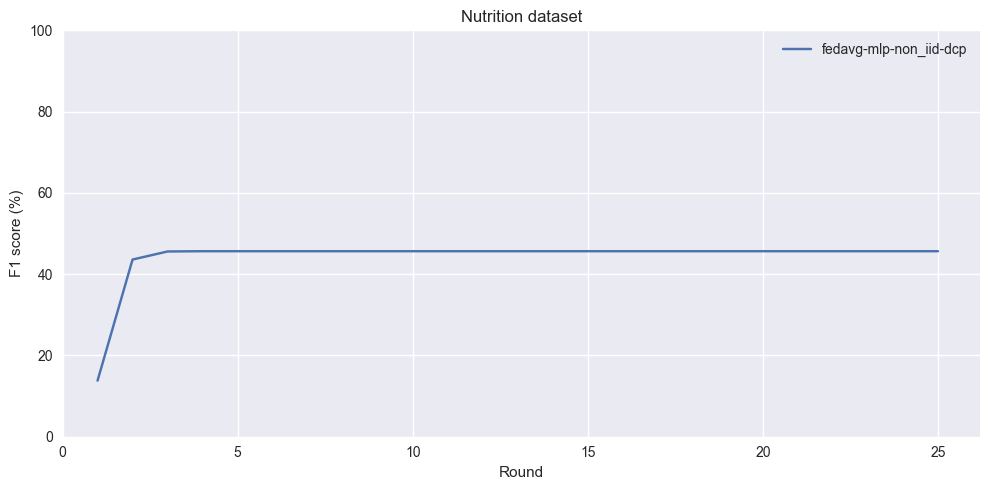

In [68]:
metric = {name: load_global_metrics(path)}
legend_map = {}
color_map = {}

plt.figure(figsize=(10, 5))
for name, df in metric.items():
    plt.plot(
        df['round'],
        df['accuracy'] * 100,
        label=legend_map.get(name, name),
        color=color_map.get(name),
    )
plt.title('Nutrition dataset')
plt.xlabel('Round')
plt.ylabel('Accuracy (%)')
plt.xlim(left=0)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
for name, df in metric.items():
    if 'macro_f1' in df.columns:
        plt.plot(
            df['round'],
            df['macro_f1'] * 100,
            label=legend_map.get(name, name),
            color=color_map.get(name),
        )
plt.title('Nutrition dataset')
plt.xlabel('Round')
plt.ylabel('F1 score (%)')
plt.xlim(left=0)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()